In [2]:
import numpy as np
import matplotlib.pyplot as plt

maze = np.array([
    [0, 0, 1, 0, 0, 0],
    [0, 2, 0, 0, 1, 0],
    [0, 0, 0, 2, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [2, 0, 1, 0, 0, 3]
])

ROWS, COLS = maze.shape
START = (0, 0)
GOAL  = (5, 5)
DIRS  = [(-1,0), (1,0), (0,-1), (0,1)]   

gamma    = 0.9
epsilon  = 0.2
episodes = 500

agents = {
    'balanced':            {'Q': np.zeros((ROWS, COLS, 4)), 'alpha_pos': 0.5, 'alpha_neg': 0.5},
    'reward seeking':      {'Q': np.zeros((ROWS, COLS, 4)), 'alpha_pos': 0.9, 'alpha_neg': 0.1},
    'punishment avoidant': {'Q': np.zeros((ROWS, COLS, 4)), 'alpha_pos': 0.1, 'alpha_neg': 0.9},
    'low DA':              {'Q': np.zeros((ROWS, COLS, 4)), 'alpha_pos': 0.1, 'alpha_neg': 0.1},
}

def step(state, action):
    r, c = state
    dr, dc = DIRS[action]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS or maze[nr, nc] == 1:
        nr, nc = r, c
    tile = maze[nr, nc]
    if tile == 3:
        reward = 10
    elif tile == 2:
        reward = -1
    else:
        reward = -0.04
    done = (tile == 3 or tile == 2)
    return (nr, nc), reward, done


def choose_action(state, Q):
    r, c = state
    if np.random.random() < epsilon:
        return np.random.randint(4)
    else:
        return np.argmax(Q[r, c])

results = {name: {'steps': [], 'deltas': []} for name in agents}
np.random.seed(11)

for name, agent in agents.items():
    Q         = agent['Q']
    alpha_pos = agent['alpha_pos']
    alpha_neg = agent['alpha_neg']

    for episode in range(episodes):
        state = START
        steps = 0

        while True:
            r, c   = state
            action = choose_action(state, Q)
            next_state, reward, done = step(state, action)
            nr, nc = next_state

            # compute TD error — identical to base
            delta = reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action]

            # D1 / D2 update — the only change from the base notebook
            if delta > 0:
                Q[r, c, action] += alpha_pos * delta   # D1: reward learning
            else:
                Q[r, c, action] += alpha_neg * delta   # D2: punishment learning

            results[name]['deltas'].append(delta)
            steps += 1
            state = next_state

            if done or steps > 500:
                break

        results[name]['steps'].append(steps)



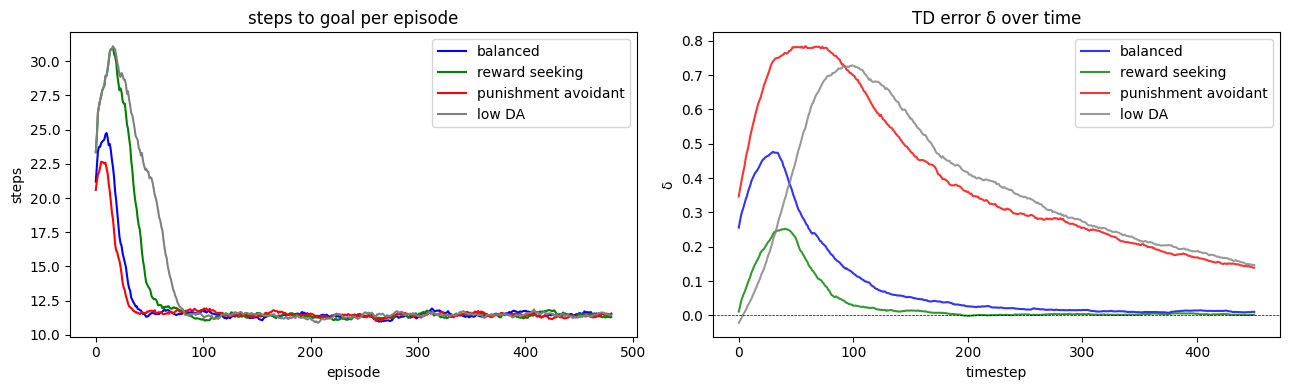

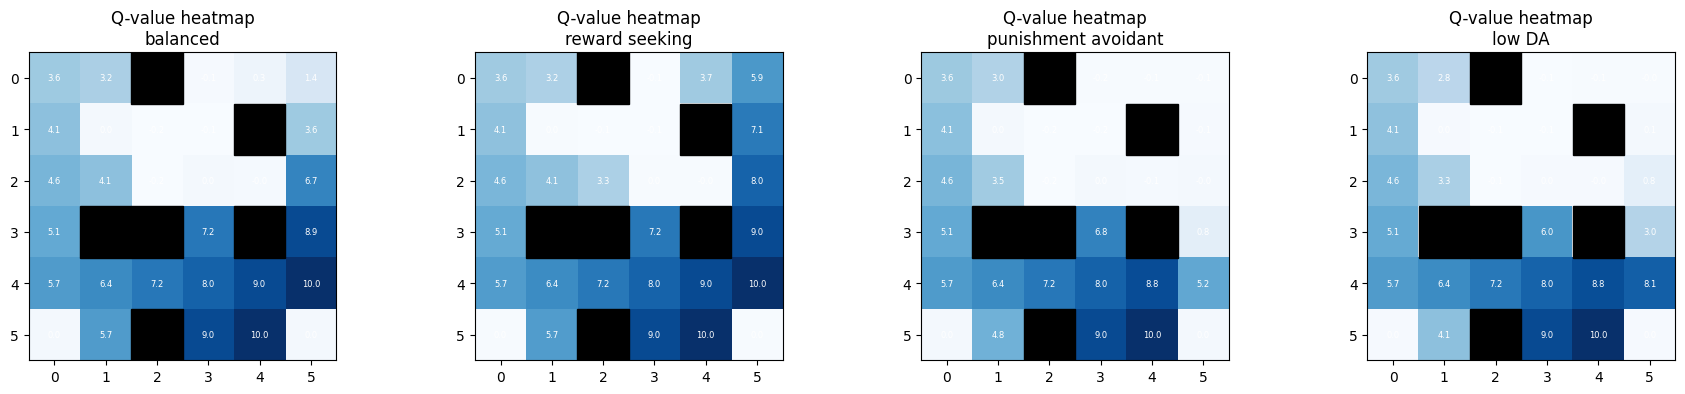

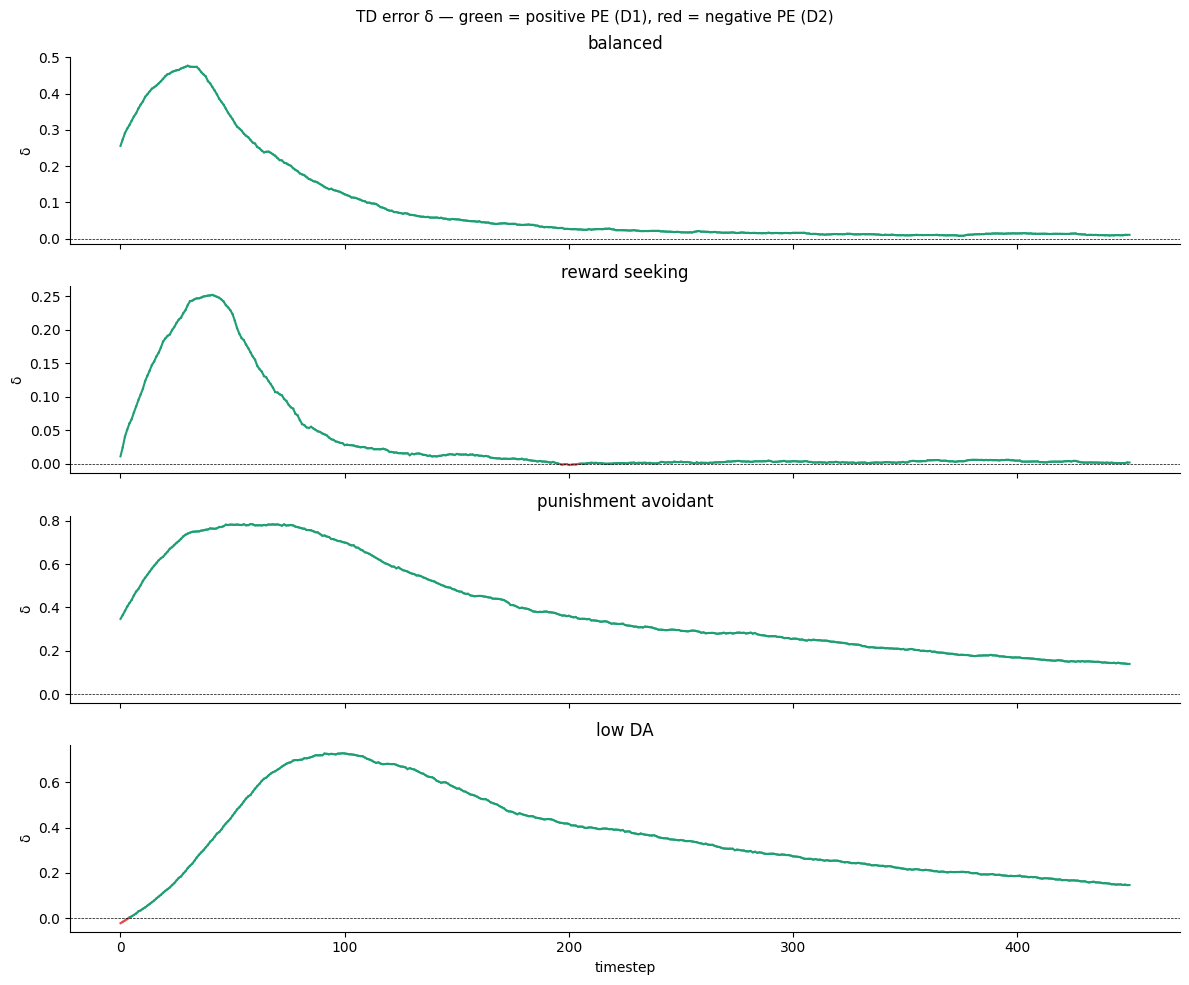

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

def smooth(data, window=20):
    return np.convolve(data, np.ones(window) / window, mode='valid')

COLORS = {
    'balanced':            'blue',
    'reward seeking':      'green',
    'punishment avoidant': 'red',
    'low DA':              'gray',
}
# steps to goal
for name in agents:
    axes[0].plot(smooth(results[name]['steps']),
                 color=COLORS[name], label=name, linewidth=1.5)
axes[0].set_title('steps to goal per episode')
axes[0].set_xlabel('episode')
axes[0].set_ylabel('steps')
axes[0].legend()

# TD error
for name in agents:
    axes[1].plot(smooth(results[name]['deltas'], window=50),
                 color=COLORS[name], label=name, linewidth=1.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('TD error δ over time')
axes[1].set_xlabel('timestep')
axes[1].set_ylabel('δ')
axes[1].legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Q-value heatmap (same as base, now one per agent)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, agent) in zip(axes, agents.items()):
    value_map = np.max(agent['Q'], axis=2)
    ax.imshow(value_map, cmap='Blues')
    ax.set_title(f'Q-value heatmap\n{name}')
    for r in range(ROWS):
        for c in range(COLS):
            if maze[r, c] == 1:
                ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black'))
            else:
                ax.text(c, r, f'{value_map[r,c]:.1f}',
                        ha='center', va='center', fontsize=6, color='white')

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Final learned policy (same as base, now one per agent)
# ─────────────────────────────────────────────────────────────────────────────

arrow_map = {0:'↑', 1:'↓', 2:'←', 3:'→'}

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for ax, (name, data) in zip(axes, results.items()):
    smoothed = smooth(data['deltas'], window=50)
    x = np.arange(len(smoothed))

    for i in range(len(smoothed) - 1):
        color = '#1D9E75' if smoothed[i] > 0 else '#E24B4A'
        ax.plot([x[i], x[i+1]], [smoothed[i], smoothed[i+1]],
                color=color, linewidth=1.5)

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_ylabel('δ')
    ax.set_title(name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('timestep')
plt.suptitle('TD error δ — green = positive PE (D1), red = negative PE (D2)', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
N_RUNS = 20   # number of times to repeat training

results = {name: {'steps': [], 'deltas': []} for name in agents}

for name, agent in agents.items():
    alpha_pos = agent['alpha_pos']
    alpha_neg = agent['alpha_neg']

    # store results across runs
    all_steps  = []
    all_deltas = []

    for run in range(N_RUNS):
        np.random.seed(run)   # different seed each run
        Q = np.zeros((ROWS, COLS, 4))   # reset Q table each run

        run_steps  = []
        run_deltas = []

        for episode in range(episodes):
            state = START
            steps = 0
            ep_deltas = []

            while True:
                r, c   = state
                action = choose_action(state, Q)
                next_state, reward, done = step(state, action)
                nr, nc = next_state

                delta = reward + gamma * np.max(Q[nr, nc]) - Q[r, c, action]

                if delta > 0:
                    Q[r, c, action] += alpha_pos * delta
                else:
                    Q[r, c, action] += alpha_neg * delta

                ep_deltas.append(delta)
                steps += 1
                state = next_state

                if done or steps > 500:
                    break

            run_steps.append(steps)
            run_deltas.append(np.mean(ep_deltas))   # mean δ per episode

        all_steps.append(run_steps)
        all_deltas.append(run_deltas)

    # average across runs — shape: (episodes,)
    results[name]['steps']  = np.mean(all_steps,  axis=0)
    results[name]['deltas'] = np.mean(all_deltas, axis=0)

    # also store std for shaded error bands
    results[name]['steps_std']  = np.std(all_steps,  axis=0)
    results[name]['deltas_std'] = np.std(all_deltas, axis=0)

In [5]:
x = np.arange(episodes)

for name in agents:
    mean = results[name]['steps']
    std  = results[name]['steps_std']
    ax.plot(mean, color=COLORS[name], label=name, linewidth=2)
    ax.fill_between(x, mean - std, mean + std,
                    color=COLORS[name], alpha=0.15)